In [1]:
import pandas as pd
import numpy as np

Loading data

In [2]:
df = pd.read_csv('../data/cleaned_fake_job_postings.csv')
print('Shape of the dataset:', df.shape)
display(df.head())

Shape of the dataset: (17880, 14)


,job_id,location,department,salary_range,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,job_description
0,1,"US, NY, New York",Marketing,Unknown,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0,NaN
1,2,"NZ, , Auckland",Success,Unknown,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...
2,3,"US, IA, Wever",Unknown,Unknown,0,1,0,Unknown,Unknown,Unknown,Unknown,Unknown,0,NaN
3,4,"US, DC, Washington",Sales,Unknown,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Account Executive - Washington DC Our passion ...
4,5,"US, FL, Fort Worth",Unknown,Unknown,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Bill Review Manager SpotSource Solutions LLC i...


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   location             17880 non-null  object
 2   department           17880 non-null  object
 3   salary_range         17880 non-null  object
 4   telecommuting        17880 non-null  int64 
 5   has_company_logo     17880 non-null  int64 
 6   has_questions        17880 non-null  int64 
 7   employment_type      17880 non-null  object
 8   required_experience  17880 non-null  object
 9   required_education   17880 non-null  object
 10  industry             17880 non-null  object
 11  function             17880 non-null  object
 12  fraudulent           17880 non-null  int64 
 13  job_description      8845 non-null   object
dtypes: int64(5), object(9)
memory usage: 1.9+ MB


None

There must be no Nan values in "job_description" but anyways let's handle it

In [4]:
df['job_description'].isna().sum()

9035

In [5]:
df['job_description'] = df['job_description'].fillna("")
print('Nan values handled.')

Nan values handled.


In [6]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   location             17880 non-null  object
 2   department           17880 non-null  object
 3   salary_range         17880 non-null  object
 4   telecommuting        17880 non-null  int64 
 5   has_company_logo     17880 non-null  int64 
 6   has_questions        17880 non-null  int64 
 7   employment_type      17880 non-null  object
 8   required_experience  17880 non-null  object
 9   required_education   17880 non-null  object
 10  industry             17880 non-null  object
 11  function             17880 non-null  object
 12  fraudulent           17880 non-null  int64 
 13  job_description      17880 non-null  object
dtypes: int64(5), object(9)
memory usage: 1.9+ MB


None

Count of real vs fraud jobs


Fraudulent distribution:
fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64


([<matplotlib.axis.XTick at 0x1f055cca000>,
 [Text(0, 0, 'Real'), Text(1, 0, 'Fraud')])

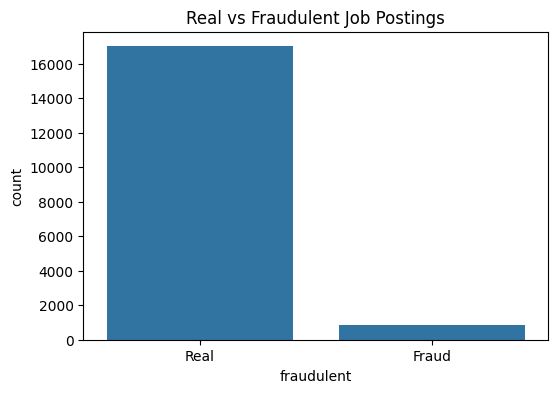

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns

print("\nFraudulent distribution:")
print(df['fraudulent'].value_counts(normalize=True))

# Highly imbalanced → will use class_weight later
plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title('Real vs Fraudulent Job Postings')
plt.xticks([0, 1], ['Real', 'Fraud'])

Binary Features vs Fraud

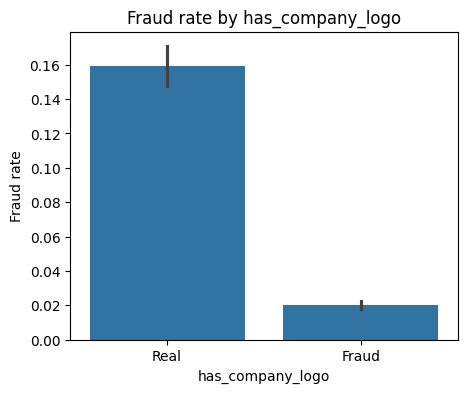

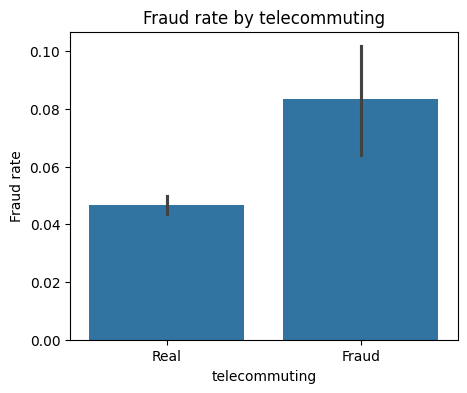

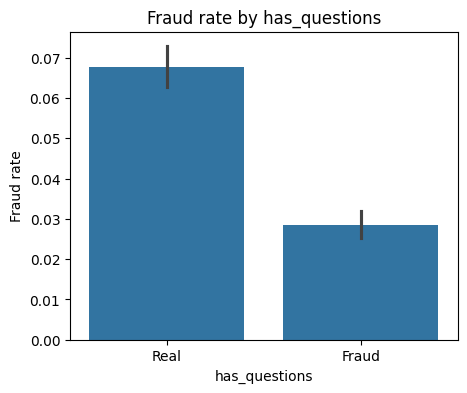

In [8]:
binary_cols = ['has_company_logo', 'telecommuting', 'has_questions']

for col in binary_cols:
    plt.figure(figsize=(5,4))

    sns.barplot(
        x=col,
        y = 'fraudulent',
        data=df,
        estimator=lambda x: sum(x)/len(x)
    )

    plt.title(f'Fraud rate by {col}')
    plt.ylabel('Fraud rate')
    plt.xlabel(col)
    # plt.show()
    plt.xticks([0, 1], ['Real', 'Fraud'])

1. Job postings without a company logo show a significantly higher fraud rate, making this a strong predictive feature.
2. Remote jobs are almost twice as likely to be fraudulent but always Remote ≠ scam, still fraud exploits remote work appeal.
3. Fraudulent jobs often skip screening questions and Legitimate employers tend to ask questions.

All these three binary features show clear, directional separation between real and fraud jobs.
So I will keep these features.

Text-Based EDA

In [9]:
# Create text length features
df['jd_char_len'] = df['job_description'].str.len()
df['jd_word_count'] = df['job_description'].str.split().str.len()

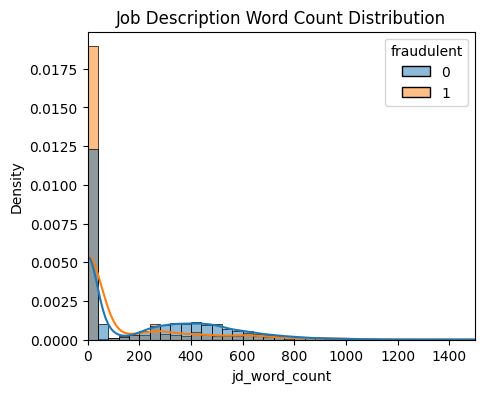

In [10]:
plt.figure(figsize=(5,4))

sns.histplot(
    data=df,
    x='jd_word_count',
    hue='fraudulent',
    bins=50,
    kde=True,
    stat='density',
    common_norm=False
)

plt.xlim(0, 1500)
plt.title('Job Description Word Count Distribution')
plt.show()

Text-based EDA showed that fraudulent job postings tend to have significantly shorter descriptions, while legitimate jobs contain more detailed information. 

In [11]:
# Common Keywords
from collections import Counter
import re

def get_top_words(text_series, n=20):
    words = ' '.join(text_series).lower()
    words = re.findall(r'\b[a-z]{3,}\b', words)
    return Counter(words).most_common(n)

fraud_words = get_top_words(df[df['fraudulent'] == 1]['job_description'])
real_words = get_top_words(df[df['fraudulent'] == 0]['job_description'])

fraud_words[:10], real_words[:10]



([('and', 5497),
  ('the', 2696),
  ('with', 1295),
  ('for', 1142),
  ('our', 798),
  ('are', 555),
  ('work', 527),
  ('experience', 499),
  ('your', 435),
  ('you', 415)],
 [('and', 193349),
  ('the', 112563),
  ('with', 50544),
  ('for', 47013),
  ('our', 39719),
  ('you', 36659),
  ('are', 25970),
  ('that', 20477),
  ('experience', 19942),
  ('work', 19870)])

So the output is dominated by high-frequency English stopwords, which appear in both real and fraud jobs.
Indicating that contextual NLP features such as TF-IDF are required rather than simple word counts.
I will do it later, maybe will create preprocessing notebook file.

Categorical Feature Analysis

In [12]:
# Fraud Rate by Category (Top Values Only)
(df.groupby('employment_type')['fraudulent'].mean().sort_values(ascending=False).head(10))

employment_type
Part-time    0.092848
Unknown      0.069432
Other        0.066079
Full-time    0.042169
Contract     0.028871
Temporary    0.008299
Name: fraudulent, dtype: float64

Interpretation:

* Part-time roles have the highest fraud rate

* Unknown / Other categories are riskier

* Full-time jobs are relatively safer

In [13]:
categorical_cols = [
    'required_experience',
    'required_education',
    'industry',
    'function',
    'location'
]

for col in categorical_cols:
    print(f"\nFraud rate by {col}:")
    print(df.groupby(col)['fraudulent'].mean().sort_values(ascending=False).head(10))


Fraud rate by required_experience:
required_experience
Executive           0.070922
Entry level         0.066370
Unknown             0.061702
Not Applicable      0.053763
Director            0.043702
Mid-Senior level    0.029667
Internship          0.026247
Associate           0.018285
Name: fraudulent, dtype: float64

Fraud rate by required_education:
required_education
Some High School Coursework          0.740741
Certification                        0.111765
High School or equivalent            0.081731
Master's Degree                      0.074519
Unknown                              0.055645
Professional                         0.054054
Unspecified                          0.043665
Doctorate                            0.038462
Some College Coursework Completed    0.029412
Associate Degree                     0.021898
Name: fraudulent, dtype: float64

Fraud rate by industry:
industry
Ranching                     1.000000
Military                     0.500000
Animation             

Fraudulent postings tend to cluster around vague or extreme experience requirements, such as entry-level or executive roles.

In [14]:
# Fraud Rate by Industry (Top Values Only)
print('Fraud Rate by Industry: ')
(df.groupby('industry')['fraudulent'].mean().sort_values(ascending=False).head(10))

Fraud Rate by Industry: 


industry
Ranching                     1.000000
Military                     0.500000
Animation                    0.400000
Oil & Energy                 0.379791
Accounting                   0.358491
Leisure, Travel & Tourism    0.276316
Computer Networking          0.272727
Executive Office             0.250000
Defense & Space              0.222222
Investment Management        0.166667
Name: fraudulent, dtype: float64

In [15]:
# Fraud Rate by function (Top Values Only)
print('Fraud Rate by Function: ')
(df.groupby('function')['fraudulent'].mean().sort_values(ascending=False).head(10))

Fraud Rate by Function: 


function
Administrative          0.188889
Financial Analyst       0.151515
Accounting/Auditing     0.136792
Distribution            0.125000
Other                   0.098462
Finance                 0.087209
Engineering             0.083828
Business Development    0.057018
Advertising             0.055556
Project Management      0.054645
Name: fraudulent, dtype: float64

Although some industries showed high fraud rates, these were driven by extremely small sample sizes. To avoid overfitting and unstable estimates, I will exclude high-cardinality categorical features such as industry and function

In [16]:
df.head()

,job_id,location,department,salary_range,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,job_description,jd_char_len,jd_word_count
0,1,"US, NY, New York",Marketing,Unknown,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0,,0,0
1,2,"NZ, , Auckland",Success,Unknown,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...,6133,901
2,3,"US, IA, Wever",Unknown,Unknown,0,1,0,Unknown,Unknown,Unknown,Unknown,Unknown,0,,0,0
3,4,"US, DC, Washington",Sales,Unknown,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Account Executive - Washington DC Our passion ...,5462,709
4,5,"US, FL, Fort Worth",Unknown,Unknown,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Bill Review Manager SpotSource Solutions LLC i...,3949,470


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   location             17880 non-null  object
 2   department           17880 non-null  object
 3   salary_range         17880 non-null  object
 4   telecommuting        17880 non-null  int64 
 5   has_company_logo     17880 non-null  int64 
 6   has_questions        17880 non-null  int64 
 7   employment_type      17880 non-null  object
 8   required_experience  17880 non-null  object
 9   required_education   17880 non-null  object
 10  industry             17880 non-null  object
 11  function             17880 non-null  object
 12  fraudulent           17880 non-null  int64 
 13  job_description      17880 non-null  object
 14  jd_char_len          17880 non-null  int64 
 15  jd_word_count        17880 non-null  int64 
dtypes: i

In [18]:
df.to_csv('../data/eda_fake_job_postings.csv', index=False)